# 04. Backtesting del portafolio óptimo

## Objetivo

Una vez obtenido el portafolio óptimo mediante el modelo de Markowitz, el siguiente paso consiste en evaluar su desempeño histórico.

Este proceso, conocido como **backtesting**, consiste en simular cómo habría evolucionado una inversión utilizando información histórica.

El desempeño del portafolio se comparará con el ETF **SPY**, utilizado como benchmark por representar el comportamiento del índice S&P 500.

Esta comparación permitirá evaluar si la estrategia optimizada genera un mayor rendimiento ajustado por riesgo que una inversión pasiva en el mercado.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [34]:
from pathlib import Path

# Ruta donde se guardarán las figuras
FIGURES_DIR = Path("../reports/figures")

# Crear la carpeta si no existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Carga de datos

Para realizar la simulación se utilizan los precios ajustados (*Adjusted Close*).

Este precio incorpora eventos corporativos como dividendos y desdoblamientos (*stock splits*), proporcionando una medida consistente del rendimiento real de cada activo.

Posteriormente se calculan los rendimientos diarios mediante la variación porcentual entre precios consecutivos.

Estos rendimientos serán la base para simular el comportamiento diario del portafolio.

In [16]:
precios = pd.read_csv(
    "../data/raw/adj_close.csv",
    index_col=0,
    parse_dates=True
)

precios.head()

,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
Date,,,,,,,,,,,
2018-01-02,40.267075,131.050781,110.130821,85.516022,35.024223,78.699913,4.922528,235.954285,107.888245,28.800240,58.185486
2018-01-03,40.260071,131.251068,111.182854,85.603157,34.947311,79.066170,5.246499,237.446808,108.962318,29.051468,59.328255
2018-01-04,40.447060,133.053604,111.174957,86.829475,35.439533,79.762077,5.274155,238.447525,109.367470,29.077749,59.410378
2018-01-05,40.907566,135.156540,112.092506,86.272079,35.431831,80.750961,5.318851,240.036545,111.986717,29.250099,59.362476
2018-01-08,40.755638,138.553009,112.234856,86.399467,35.378002,80.833366,5.481824,240.475479,112.438950,29.682447,59.629353


In [17]:
returns = precios.pct_change().dropna()

returns.head()

,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
Date,,,,,,,,,,,
2018-01-03,-0.000174,0.001528,0.009553,0.001019,-0.002196,0.004654,0.065814,0.006325,0.009955,0.008723,0.019640
2018-01-04,0.004645,0.013733,-0.000071,0.014326,0.014085,0.008802,0.005271,0.004214,0.003718,0.000905,0.001384
2018-01-05,0.011385,0.015805,0.008253,-0.006419,-0.000217,0.012398,0.008475,0.006664,0.023949,0.005927,-0.000806
2018-01-08,-0.003714,0.025130,0.001270,0.001477,-0.001519,0.001020,0.030641,0.001829,0.004038,0.014781,0.004496
2018-01-09,-0.000115,0.002409,0.015857,0.005069,0.005000,-0.000680,-0.000270,0.002264,-0.001927,-0.012007,-0.004246


## Construcción del portafolio

Se utilizan los pesos obtenidos durante la optimización de Markowitz.

Cada rendimiento diario del portafolio se calcula como una combinación ponderada de los rendimientos individuales de los activos.

La expresión utilizada es

$
R_p=\sum_{i=1}^{n}w_iR_i
$

donde:

- $w_i$ corresponde al peso asignado al activo.
- $R_i$ representa el rendimiento diario del activo.

De esta manera se obtiene una única serie temporal correspondiente al rendimiento diario del portafolio completo.

In [18]:
pesos = np.array([
    0.040869,
    0.098564,
    0.040314,
    0.007502,
    0.110664,
    0.136248,
    0.317811,
    0.017628,
    0.025323,
    0.188270,
    0.016806
])

In [19]:
portfolio_returns = returns.dot(pesos)

portfolio_returns.head()

Date
2018-01-03    0.024180
2018-01-04    0.006443
2018-01-05    0.008492
2018-01-08    0.015089
2018-01-09   -0.001056
dtype: float64

In [20]:
spy_returns = returns["SPY"]

## Simulación de una inversión

Para facilitar la interpretación de los resultados se simula una inversión inicial de **100 dólares** tanto en el portafolio optimizado como en el ETF SPY.

El valor acumulado se obtiene mediante capitalización compuesta:

$
Valor_t = Valor_0\prod_{i=1}^{t}(1+R_i)
$

donde:

- $Valor_0$ corresponde a la inversión inicial.
- $R_i$ representa el rendimiento diario.

Esta metodología reproduce el crecimiento real de una inversión a lo largo del tiempo.

In [21]:
capital_portfolio = 100 * (1 + portfolio_returns).cumprod()

In [22]:
capital_spy = 100 * (1 + spy_returns).cumprod()

## Evolución del portafolio frente al S&P 500

La siguiente figura muestra la evolución histórica de una inversión inicial de **100 dólares** realizada en dos estrategias:

- Portafolio optimizado mediante Markowitz.
- ETF SPY como representación del mercado estadounidense.

Durante los primeros años ambas estrategias presentan un comportamiento similar. Sin embargo, aproximadamente a partir de **2020** el portafolio optimizado comienza a superar de manera significativa al índice de referencia.

Este comportamiento se explica principalmente por la elevada participación asignada a **NVIDIA (NVDA)** dentro del portafolio óptimo.

Entre 2020 y 2024 NVIDIA experimentó uno de los mayores crecimientos del mercado bursátil, impulsado por factores como:

- Expansión del mercado de inteligencia artificial.
- Incremento en la demanda de GPU para centros de datos.
- Crecimiento de aplicaciones de Machine Learning.
- Desarrollo de infraestructura para modelos de IA generativa.

Al asignar aproximadamente un **31.8 %** del capital a NVIDIA, el algoritmo logró capturar gran parte de este crecimiento, generando un rendimiento superior al del índice S&P 500.

No obstante, este mayor rendimiento también implica asumir una mayor volatilidad, lo cual es consistente con la teoría moderna de portafolios.

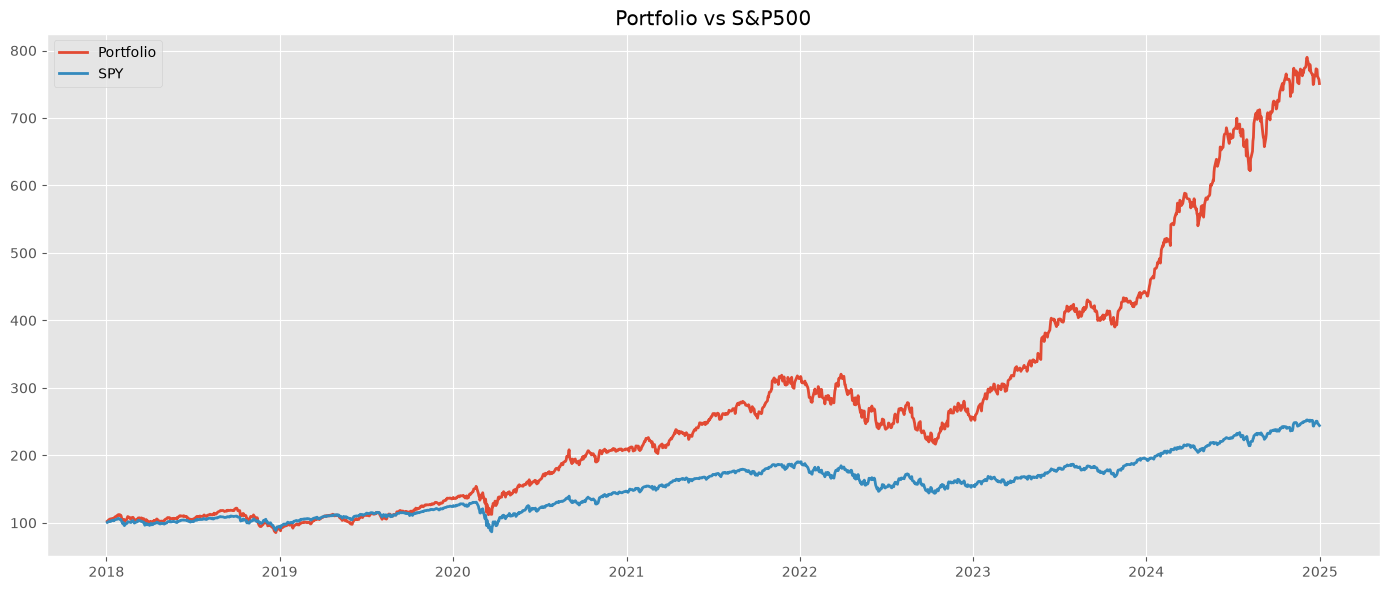

In [37]:
plt.figure(figsize=(14,6))

plt.plot(
    capital_portfolio,
    label="Portfolio",
    linewidth=2
)

plt.plot(
    capital_spy,
    label="SPY",
    linewidth=2
)

plt.legend()

plt.title("Portfolio vs S&P500")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "portfolio_vs_spy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Interpretación de los resultados

El backtesting muestra que el portafolio optimizado habría generado un crecimiento considerablemente superior al benchmark durante el período analizado.

Esto confirma que la optimización de Markowitz fue capaz de identificar una combinación eficiente entre activos con alto potencial de crecimiento y activos defensivos que contribuyen a reducir el riesgo.

Es importante destacar que estos resultados corresponden únicamente al período histórico analizado y no garantizan rendimientos futuros.

La composición óptima de un portafolio depende del horizonte temporal, las condiciones del mercado y la evolución de los activos considerados.

## Compound Annual Growth Rate (CAGR)

El CAGR representa el crecimiento anual compuesto del portafolio durante todo el horizonte de inversión.

A diferencia del rendimiento acumulado, esta métrica suaviza las variaciones y expresa cuál habría sido el crecimiento promedio anual.

Se calcula mediante:

$
CAGR=
\left(
\frac{V_f}{V_i}
\right)^{1/n}-1
$

donde:

- $V_f$: valor final del portafolio.
- $V_i$: valor inicial.
- $n$: número de años.

Cuanto mayor sea el CAGR, mayor fue la rentabilidad obtenida de manera sostenida.

In [26]:
# ======================================
# Métricas adicionales del portafolio
# ======================================

# Número de años del periodo
years = len(portfolio_returns) / 252

# Valor inicial = 1
initial_value = 1
final_value = capital_portfolio.iloc[-1]

# CAGR
cagr = (final_value / initial_value) ** (1 / years) - 1

print(f"CAGR: {cagr:.2%}")

CAGR: 158.07%


## Maximum Drawdown

El Maximum Drawdown representa la mayor pérdida acumulada que experimentó el portafolio desde un máximo histórico hasta el mínimo posterior.

Formalmente,

$
Drawdown_t=
\frac{V_t}{\max(V)}-1
$

Esta métrica es ampliamente utilizada para evaluar el riesgo de una estrategia de inversión.

Mientras más cercano a cero sea el Maximum Drawdown, menor fue la pérdida máxima sufrida por el inversionista.

In [28]:
# ======================================
# Maximum Drawdown
# ======================================

rolling_max = capital_portfolio.cummax()

drawdown = capital_portfolio / rolling_max - 1

max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -32.38%


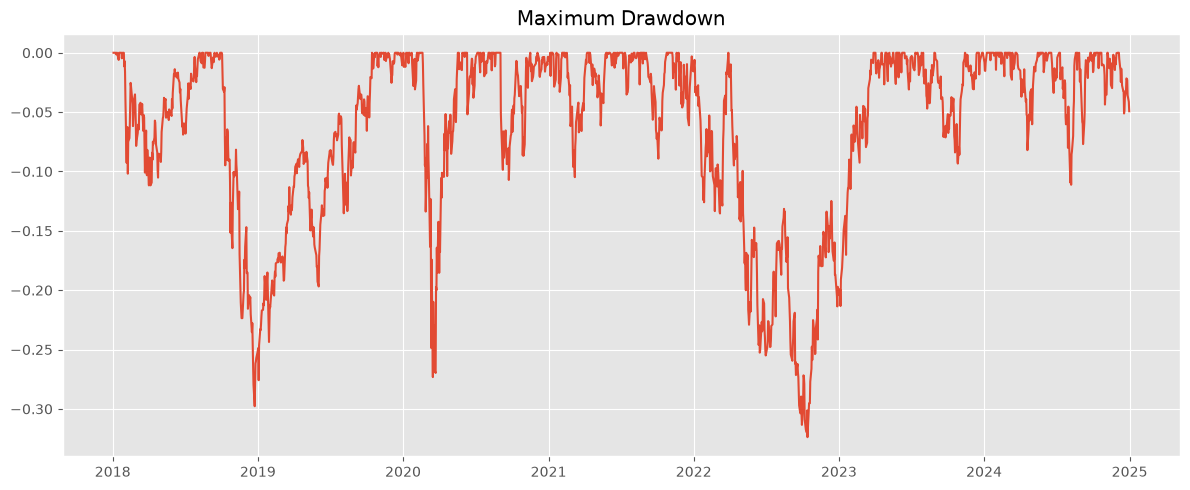

In [38]:
plt.figure(figsize=(12,5))

plt.plot(drawdown)

plt.title("Maximum Drawdown")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Calmar Ratio

El Calmar Ratio compara el rendimiento anual compuesto del portafolio con la mayor pérdida registrada (Maximum Drawdown).

$
Calmar=
\frac{CAGR}{|Maximum\ Drawdown|}
$

Valores elevados indican que el portafolio obtiene un alto rendimiento en relación con el riesgo máximo asumido.

In [30]:
calmar = cagr / abs(max_drawdown)

print(f"Calmar Ratio: {calmar:.2f}")

Calmar Ratio: 4.88


## Sortino Ratio

El Sortino Ratio es una variante del Sharpe Ratio que únicamente penaliza la volatilidad negativa.

Mientras el Sharpe considera toda la volatilidad, el Sortino únicamente tiene en cuenta los rendimientos inferiores al objetivo.

$
Sortino=
\frac{R_p-R_f}{\sigma_d}
$

donde:

- $R_p$: rendimiento del portafolio.
- $R_f$: tasa libre de riesgo.
- $\sigma_d$: desviación estándar de los retornos negativos.

Esta medida proporciona una evaluación más precisa cuando el inversionista únicamente considera las pérdidas como riesgo.

In [31]:
rf = 0.02

downside = portfolio_returns[portfolio_returns < 0]

downside_std = downside.std() * np.sqrt(252)

sortino = (portfolio_returns.mean()*252-rf)/downside_std

print(f"Sortino Ratio: {sortino:.2f}")

Sortino Ratio: 1.60


## Rolling Volatility

La volatilidad móvil permite analizar cómo cambia el riesgo del portafolio a lo largo del tiempo.

En este estudio se utiliza una ventana de 63 días bursátiles (aproximadamente un trimestre), permitiendo identificar periodos de mayor incertidumbre en los mercados financieros.

Incrementos abruptos suelen coincidir con eventos de alta volatilidad, como crisis económicas o choques macroeconómicos.

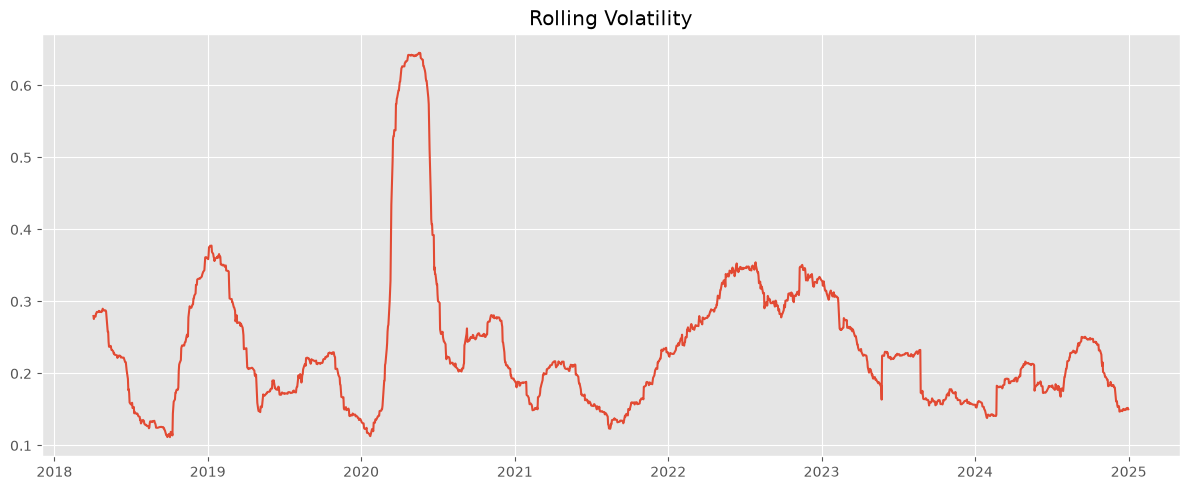

In [39]:
plt.figure(figsize=(12,5))

plt.plot(rolling_vol)

plt.title("Rolling Volatility")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Rolling Sharpe Ratio

El Rolling Sharpe Ratio muestra cómo evoluciona la eficiencia riesgo-retorno del portafolio a lo largo del tiempo.

Un incremento del indicador implica que el portafolio está generando una mayor rentabilidad por unidad de riesgo, mientras que reducciones del índice evidencian periodos de menor eficiencia.

Esta métrica resulta útil para identificar cambios estructurales en el comportamiento del portafolio.

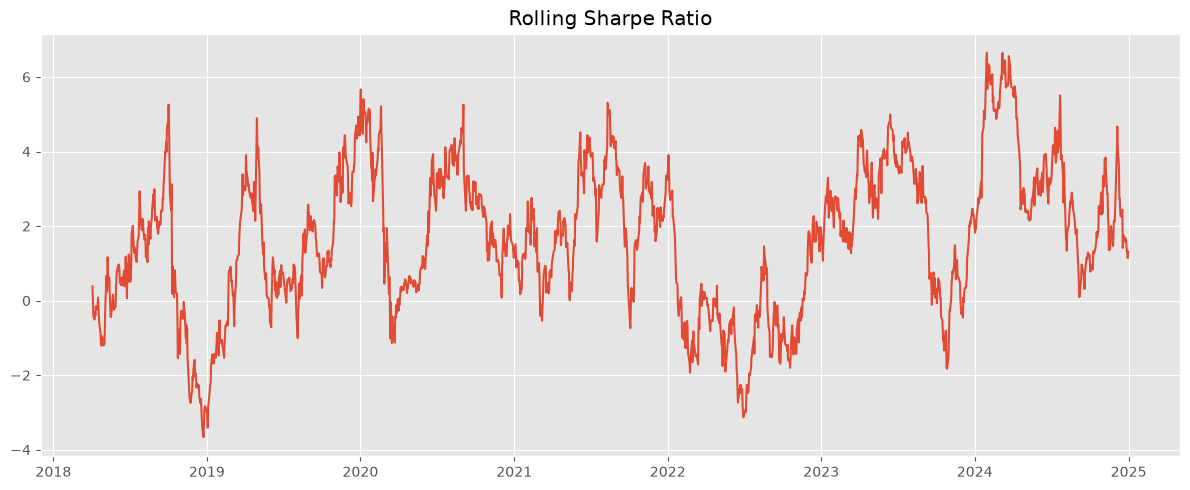

In [40]:
plt.figure(figsize=(12,5))

plt.plot(rolling_sharpe)

plt.title("Rolling Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rolling_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusiones

Los resultados del backtesting permiten extraer las siguientes conclusiones:

- La estrategia optimizada mediante Markowitz superó al índice S&P 500 durante el período analizado.
- La diversificación permitió mejorar la relación entre riesgo y rendimiento.
- La alta ponderación asignada a NVIDIA fue el principal impulsor del crecimiento del portafolio.
- La simulación evidencia la utilidad de los modelos cuantitativos para apoyar la toma de decisiones de inversión.
- El análisis demuestra que la optimización de portafolios constituye una herramienta valiosa para construir estrategias de inversión más eficientes que una inversión pasiva, siempre considerando que el desempeño histórico no garantiza resultados futuros.
- Los indicadores de desempeño confirman que el portafolio optimizado mediante el modelo de Markowitz logró un equilibrio favorable entre rentabilidad y riesgo.
- El elevado CAGR (158.07%) evidencia un crecimiento sostenido del capital durante el período analizado, impulsado principalmente por el excelente comportamiento del sector tecnológico.
- El Maximum Drawdown de -32.38% muestra que, aunque el portafolio enfrentó caídas importantes durante episodios de alta incertidumbre, especialmente en 2020, posteriormente recuperó dichas pérdidas y continuó su tendencia de crecimiento.
- El Calmar Ratio de 4.88 indica que la rentabilidad obtenida compensa ampliamente la mayor pérdida histórica registrada, reflejando una relación riesgo-retorno muy favorable.
- Finalmente, el Sortino Ratio de 1.60 demuestra que el portafolio mantiene un buen desempeño incluso cuando el riesgo se evalúa únicamente considerando los movimientos negativos del mercado, confirmando una adecuada gestión del riesgo de pérdida.
- En conjunto, estos resultados respaldan la efectividad del modelo de Markowitz para construir un portafolio diversificado que maximiza el rendimiento esperado manteniendo un nivel de riesgo controlado.